In [1]:
%load_ext autoreload
%autoreload 2

# autoreload picks up changes to src/ files automatically on each cell run,
# so edits to .py files take effect without restarting the kernel

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))  # add project root so `from src...` imports work

from src.fetch_data import fetch_universe_prices, compute_returns, save_data, UNIVERSE, START_DATE, END_DATE
from src.signals import compute_all_signals, SIGNAL_LIBRARY
from src.evaluation import compute_forward_returns, compute_ic_series, summarize_ic, compute_decay_curve
from src.walk_forward import evaluate_signal_walk_forward
from src.combination import combine_signals
from src.visualize import plot_ic_series, plot_decay_curves, plot_cumulative_ic

import pandas as pd

In [2]:
# Pulls close prices and volume for all 39 tickers in the universe.
# This is the only slow step (a handful of batched API calls) — everything
# downstream is fast since it's just math on the cached DataFrames.
close, volume = fetch_universe_prices()
returns = compute_returns(close)

print(f"Close shape: {close.shape}")
close.tail()

Fetching batch 1 (20 tickers)...


[*********************100%***********************]  20 of 20 completed


Fetching batch 2 (20 tickers)...


[*********************100%***********************]  20 of 20 completed


Close shape: (1901, 40)


Ticker,AAPL,ADBE,AIG,AMD,AMZN,BAC,CRM,CVX,GOOGL,GS,...,KO,NEE,NFLX,PEP,PFE,PG,T,UNH,UPS,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,327.739990,227.160004,80.239998,544.429993,247.550003,61.220001,170.059998,191.070007,347.149994,1085.560059,...,81.970001,87.930000,68.669998,135.000000,24.511204,147.002625,22.260000,436.350006,116.339996,110.389999
2026-07-22,325.890015,218.360001,78.250000,552.330017,244.850006,61.619999,163.000000,192.979996,342.089996,1098.199951,...,82.199997,89.410004,68.529999,135.649994,24.393267,148.024994,23.040001,431.309998,115.839996,109.330002
2026-07-23,321.660004,212.169998,78.160004,539.690002,233.660004,61.279999,156.929993,194.419998,317.690002,1074.719971,...,81.169998,89.790001,68.889999,134.949997,24.580000,145.880997,22.959999,423.559998,114.099998,108.400002
2026-07-24,333.019989,225.110001,79.059998,521.950012,232.110001,62.049999,163.660004,194.789993,319.739990,1061.229980,...,82.250000,89.779999,70.089996,136.639999,24.540001,147.410004,24.129999,420.739990,114.790001,109.470001
2026-07-27,336.910004,237.750000,79.160004,494.950012,231.389999,62.130001,173.600006,190.000000,326.559998,1048.229980,...,84.070000,88.830002,70.400002,139.789993,24.670000,148.630005,24.420000,417.640015,112.949997,111.739998


In [3]:
# Quick check: make sure we don't have any tickers that failed to download
# (would show up as an all-NaN column) before running any signal logic on them.
print("Tickers with missing data:", close.columns[close.isna().all()].tolist())
print(f"Date range: {close.index.min()} to {close.index.max()}")

Tickers with missing data: []
Date range: 2019-01-02 00:00:00 to 2026-07-27 00:00:00


In [4]:
save_data(close, volume, returns)

Saved close, volume, returns to /Users/paulgrajzl/Documents/Quant-Projects/alpha-signal-research/data/


In [5]:
# Each signal is a DataFrame shaped (dates x tickers) — same shape as `close`,
# so a signal value on a given date is directly comparable across all stocks
# in the universe on that same date. This cross-sectional shape is what
# makes the IC calculation possible.
signals = compute_all_signals(close, volume)

for name, df in signals.items():
    print(f"{name}: {df.shape}, non-null values: {df.notna().sum().sum()}")

Momentum_12_1: (1901, 40), non-null values: 65960
Short_Term_Reversal: (1901, 40), non-null values: 75840
Volume_Spike: (1901, 40), non-null values: 75280
Low_Volatility: (1901, 40), non-null values: 73640


In [6]:
# Momentum should be smooth/slow-moving (12-month lookback);
# reversal should look noisier (5-day lookback) — good gut check
# that nothing is obviously broken before evaluating.
signals["Momentum_12_1"].tail()

Ticker,AAPL,ADBE,AIG,AMD,AMZN,BAC,CRM,CVX,GOOGL,GS,...,KO,NEE,NFLX,PEP,PFE,PG,T,UNH,UPS,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,0.416764,-0.466470,-0.066777,2.422957,0.080750,0.213530,-0.416630,0.205693,0.994380,0.579412,...,0.168767,0.175273,-0.360094,0.030738,0.102236,-0.009316,-0.155778,0.456566,0.129523,0.243132
2026-07-22,0.403371,-0.469920,-0.032024,2.513567,0.015220,0.234619,-0.422790,0.218546,0.844700,0.598643,...,0.167152,0.162827,-0.409051,0.032329,0.106044,-0.026664,-0.165948,0.480016,0.158898,0.235076
2026-07-23,0.378114,-0.470513,-0.037621,2.359940,0.029191,0.238674,-0.413034,0.222011,0.814139,0.594026,...,0.185536,0.146927,-0.388108,0.011190,0.052007,-0.026367,-0.140408,0.473750,0.118331,0.256322
2026-07-24,0.374003,-0.472239,-0.019524,2.276016,0.026195,0.225334,-0.423498,0.166607,0.820297,0.531092,...,0.198419,0.238083,-0.389521,0.015398,0.014193,-0.018503,-0.167015,0.424458,0.095715,0.254128
2026-07-27,0.292298,-0.479647,-0.032730,2.285036,-0.022478,0.228716,-0.434213,0.151600,0.793675,0.510791,...,0.196781,0.253849,-0.399539,0.003695,-0.001022,-0.044555,-0.170236,0.531548,0.139445,0.208572


In [7]:
# Full-sample IC (not yet walk-forward) — this is a first-pass sanity check
# to confirm the IC calculation itself works and signals show *some* signal
# before we bother with the more rigorous out-of-sample walk-forward version.
HORIZON = 5  # forward return window in trading days

fwd_returns_5d = compute_forward_returns(close, horizon=HORIZON)

ic_results = {}
for name, sig_df in signals.items():
    ic_series = compute_ic_series(sig_df, fwd_returns_5d)
    ic_results[name] = ic_series
    print(f"\n{name}:")
    print(pd.Series(summarize_ic(ic_series)).round(4))


Momentum_12_1:
Mean IC                 0.0263
IC Std                  0.3240
Information Ratio       0.0812
% Positive IC           0.5596
N Observations       1644.0000
dtype: float64

Short_Term_Reversal:
Mean IC                 0.0012
IC Std                  0.2802
Information Ratio       0.0044
% Positive IC           0.4923
N Observations       1891.0000
dtype: float64

Volume_Spike:
Mean IC                 0.0037
IC Std                  0.1854
Information Ratio       0.0198
% Positive IC           0.5093
N Observations       1877.0000
dtype: float64

Low_Volatility:
Mean IC                -0.0168
IC Std                  0.3478
Information Ratio      -0.0482
% Positive IC           0.4733
N Observations       1836.0000
dtype: float64


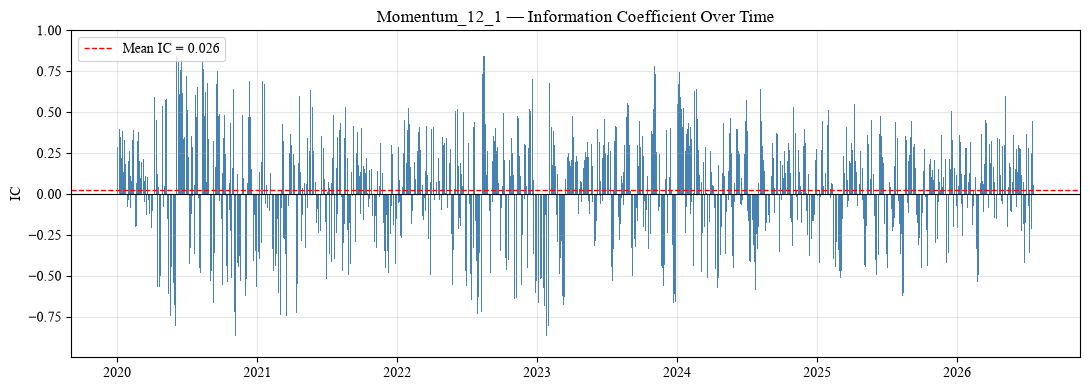

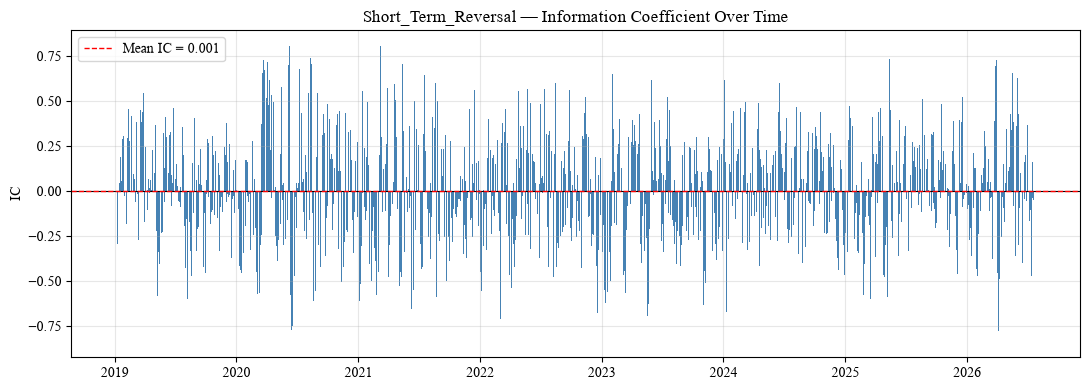

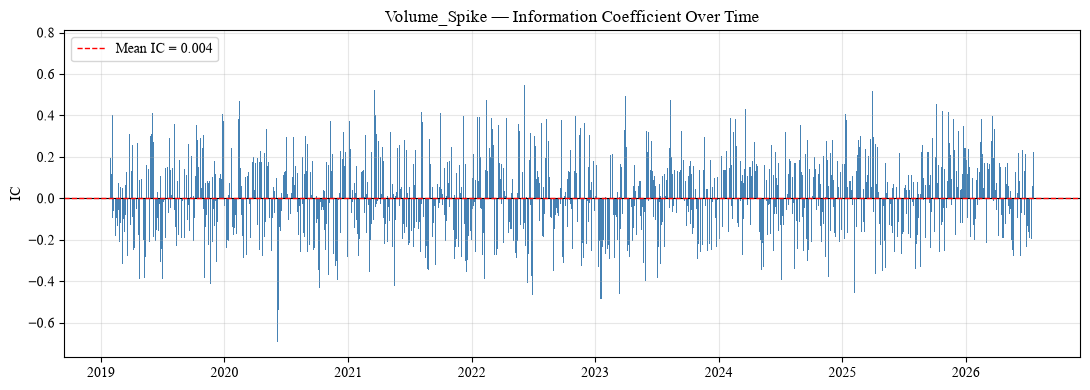

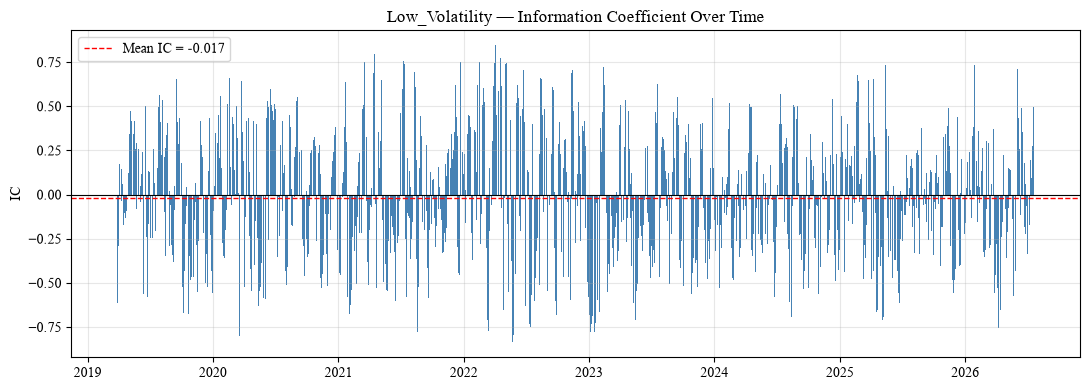

In [8]:
# Bar chart of IC per date, with the mean IC line overlaid.
# A signal with consistently same-sign bars (even if individually noisy)
# and a mean IC clearly away from 0 is a good sign; a mean IC near 0
# means the signal isn't really predicting anything on average.
for name, ic_series in ic_results.items():
    plot_ic_series(ic_series, name)

In [9]:
# For each signal, compute mean IC at several forward horizons (1, 5, 10,
# 20, 40 days). A signal that's strong at 1 day but fades to ~0 by 20 days
# is a fast, short-lived signal; one that stays elevated further out is
# more persistent (and often more useful for lower-turnover strategies).
decay_results = {}
for name, sig_df in signals.items():
    decay_results[name] = compute_decay_curve(sig_df, close, horizons=(1, 5, 10, 20, 40))

decay_df = pd.DataFrame(decay_results)
decay_df.round(4)

,Momentum_12_1,Short_Term_Reversal,Volume_Spike,Low_Volatility
1,0.0244,0.0031,-0.0041,-0.0038
5,0.0263,0.0012,0.0037,-0.0168
10,0.0259,0.0007,-0.0013,-0.0237
20,0.0315,0.0025,-0.0011,-0.0331
40,0.0348,-0.0042,-0.0021,-0.0474


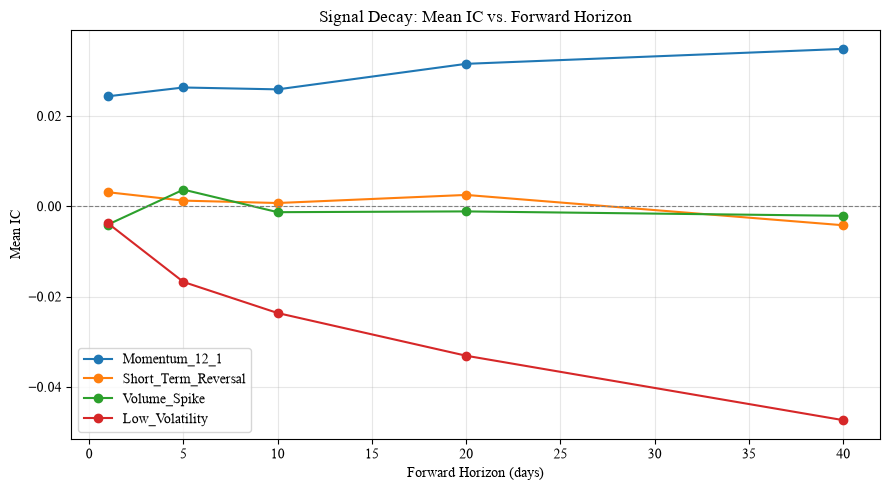

In [10]:
plot_decay_curves(decay_results)

In [11]:
# This is the methodologically important step. Instead of computing IC
# on the full sample (which implicitly "peeks" at the whole history at
# once), we only ever evaluate IC on TEST windows that come strictly
# after the corresponding TRAIN window — closer to how you'd actually
# validate a signal before trusting it going forward.
walk_forward_results = {}
for name, sig_df in signals.items():
    oos_ic = evaluate_signal_walk_forward(sig_df, close, horizon=HORIZON,
                                            train_years=2, test_months=6)
    walk_forward_results[name] = oos_ic
    print(f"\n{name} (out-of-sample):")
    print(pd.Series(summarize_ic(oos_ic)).round(4))


Momentum_12_1 (out-of-sample):
Mean IC                 0.0235
IC Std                  0.3031
Information Ratio       0.0774
% Positive IC           0.5608
N Observations       1398.0000
dtype: float64

Short_Term_Reversal (out-of-sample):
Mean IC                -0.0038
IC Std                  0.2749
Information Ratio      -0.0138
% Positive IC           0.4843
N Observations       1398.0000
dtype: float64

Volume_Spike (out-of-sample):
Mean IC                 0.0079
IC Std                  0.1851
Information Ratio       0.0425
% Positive IC           0.5165
N Observations       1398.0000
dtype: float64

Low_Volatility (out-of-sample):
Mean IC                -0.0236
IC Std                  0.3520
Information Ratio      -0.0670
% Positive IC           0.4571
N Observations       1398.0000
dtype: float64


In [12]:
# The comparison itself is the interesting result: if a signal's
# full-sample IC looks great but its walk-forward IC is much weaker,
# that's a sign the full-sample number was partly an artifact of
# hindsight rather than a genuinely stable, tradeable signal.
comparison_rows = []
for name in signals.keys():
    full_ic = ic_results[name].mean()
    oos_ic = walk_forward_results[name].mean()
    comparison_rows.append({"Signal": name, "Full-Sample IC": full_ic, "Walk-Forward IC": oos_ic})

pd.DataFrame(comparison_rows).round(4)

,Signal,Full-Sample IC,Walk-Forward IC
0,Momentum_12_1,0.0263,0.0235
1,Short_Term_Reversal,0.0012,-0.0038
2,Volume_Spike,0.0037,0.0079
3,Low_Volatility,-0.0168,-0.0236


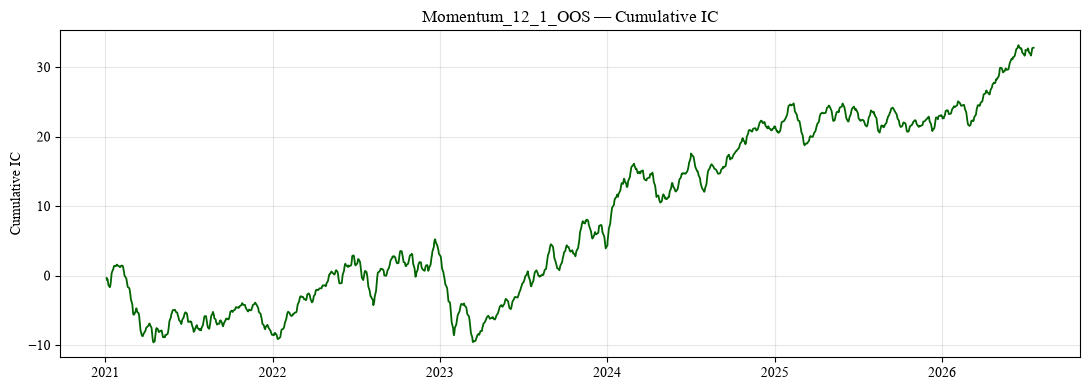

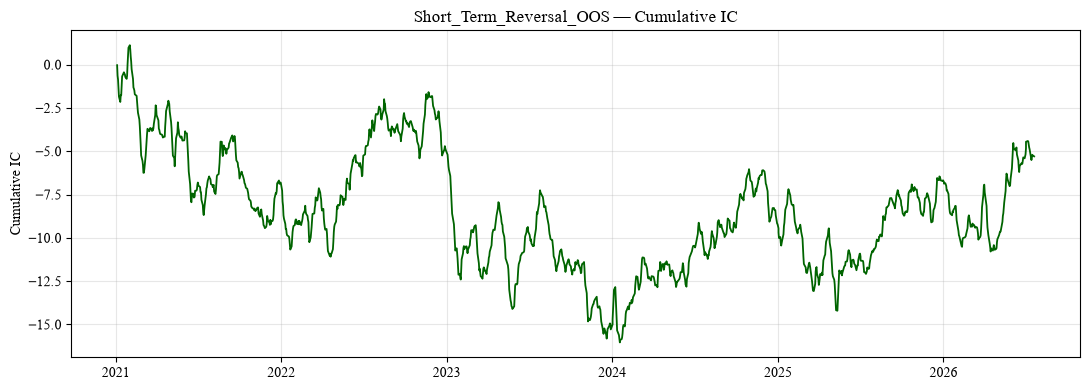

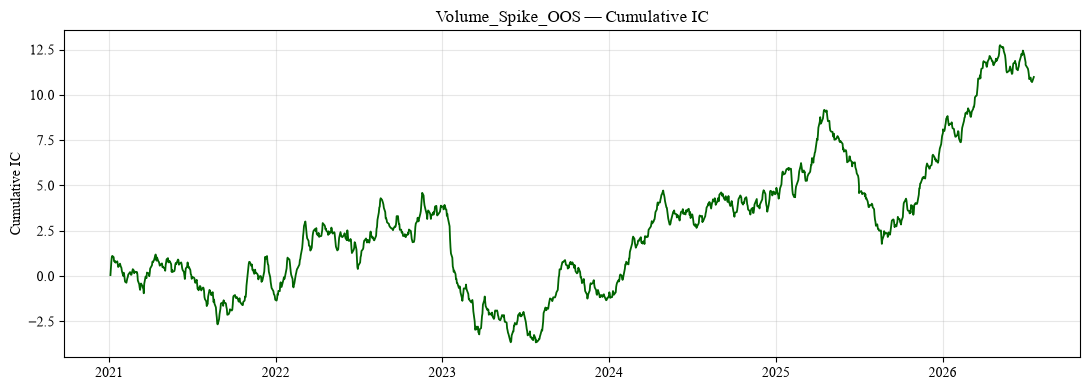

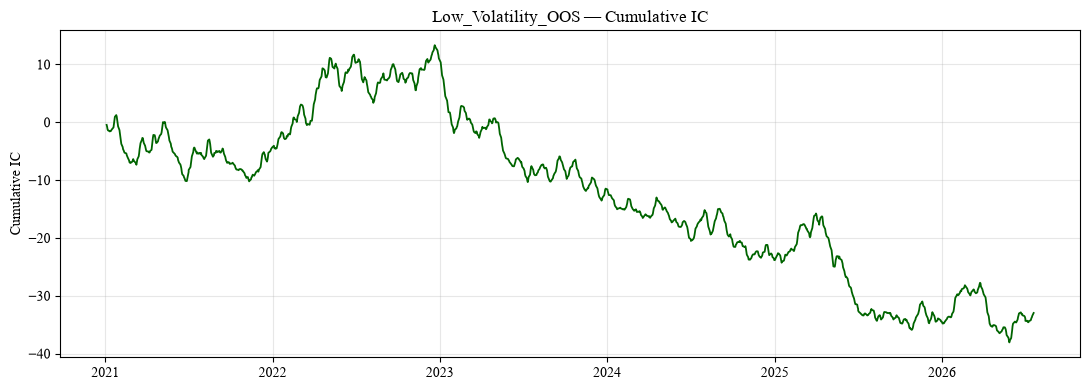

In [13]:
for name, oos_ic in walk_forward_results.items():
    plot_cumulative_ic(oos_ic, f"{name}_OOS")

Combined signal:
Mean IC                 0.0107
IC Std                  0.2811
Information Ratio       0.0382
% Positive IC           0.5444
N Observations       1644.0000
dtype: float64


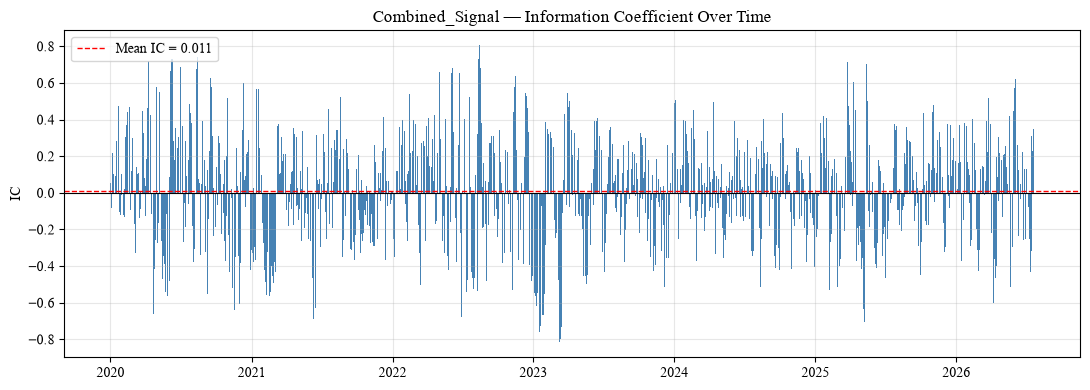

In [14]:
# Equal-weighted blend of all four signals (each z-scored cross-sectionally
# first so they're on comparable scales before averaging).
combined = combine_signals(signals)

combined_ic = compute_ic_series(combined, fwd_returns_5d)
print("Combined signal:")
print(pd.Series(summarize_ic(combined_ic)).round(4))

plot_ic_series(combined_ic, "Combined_Signal")

Combined signal (out-of-sample):
Mean IC                 0.0059
IC Std                  0.2719
Information Ratio       0.0217
% Positive IC           0.5365
N Observations       1398.0000
dtype: float64


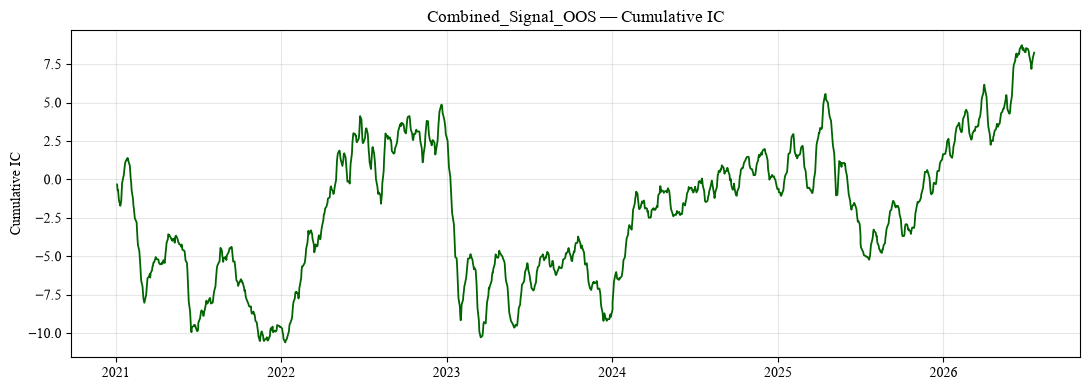

In [15]:
combined_oos_ic = evaluate_signal_walk_forward(combined, close, horizon=HORIZON,
                                                  train_years=2, test_months=6)
print("Combined signal (out-of-sample):")
print(pd.Series(summarize_ic(combined_oos_ic)).round(4))

plot_cumulative_ic(combined_oos_ic, "Combined_Signal_OOS")